In [19]:
"""
Figure Creation for Photodetection of Squeezed Light: a Whittaker-Shannon Analysis by Kranias et. al.

"""
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy as sc
fsize = 17
plt.rcParams['axes.labelsize'] = fsize
plt.rcParams['axes.titlesize'] = fsize
plt.rcParams['xtick.labelsize'] = fsize
plt.rcParams['ytick.labelsize'] = fsize

In [2]:
# r_nm elements and r matrix of double Gaussian joint amplitude where ratio = Tc/Tp
# f is a "fineness" paramter to adjust resolution

def rnm_dg(n,m,ratio):
    return np.exp( -np.pi * ((n-m)**2) / 4 - ((ratio)**2) * np.pi * ((n+m)**2) / 4)

def r_dg_f(num,k,f,ratio):
    r = [[rnm_dg(n/f,(m-k)/f,ratio) for n in range(-num,num)] for m in range(-num,num)]
    return np.array(r) / f


# r_nm elemnts and r matrix of CW double Gaussian joint amplitude

def rnm_dg_CW(n,m):
    return np.exp( -np.pi * ((n-m)**2) / 4)

def r_dg_f_CW(num,k,f):
    r = [[rnm_dg_CW(n/f,(m-k)/f) for n in range(-num,num)] for m in range(-num,num)]
    return np.array(r) / f


# functions for homodyne detection

# E matrix
def Emat(w, dim, Tc, fine_param):
    tau = Tc / fine_param
    Emat = [[np.exp( (0+1j) * w * (n-m) * tau) for n in range(dim)] for m in range(dim)]
    return Emat

# spectrum V(omega)
def V(w,theta,U,sinhQ,coshQ,sinh2Q,Tc,fine_param):
    dim = len(U)
    E = Emat(w,dim,Tc,fine_param)
    Matrix1 = np.identity(dim) + np.matmul(E,sinh2Q) + np.matmul(np.transpose(E),sinh2Q)
    Matrix2 = np.exp(-2*(0+1j)*theta)*np.linalg.multi_dot([E,np.conjugate(sinhQ),np.conjugate(coshQ),np.conjugate(U)])
    Matrix3 = np.exp(2*(0+1j)*theta)*np.linalg.multi_dot([np.transpose(E),sinhQ,coshQ,U])
    return np.trace(Matrix1 + Matrix2 + Matrix3)

# measured CW squeezing and anti-squeezing ONLY WHEN U=I
def Sq(w,U,sinhQ,coshQ,sinh2Q,Tc,fine_param):
    return V(w,np.pi/2,U,sinhQ,coshQ,sinh2Q,Tc,fine_param)/len(U)

def anti_Sq(w,U,sinhQ,coshQ,sinh2Q,Tc,fine_param):
    return V(w,0,U,sinhQ,coshQ,sinh2Q,Tc,fine_param)/len(U)

# returns K given N and M
def Kmat(N,M):
    return np.block([[np.real(N)+np.real(M),np.imag(N)+np.imag(M)],[np.imag(M)-np.imag(N),np.real(N)-np.real(M)]])




# functions for getting photon number and coincidence probabilities

#function to generate integer partitions (https://jeromekelleher.net/generating-integer-partitions.html)
def int_part(n):
    a = [0 for i in range(n + 1)]
    k = 1
    y = n - 1
    while k != 0:
        x = a[k - 1] + 1
        k -= 1
        while 2 * x <= y:
            a[k] = x
            y -= x
            k += 1
        l = k + 1
        while x <= y:
            a[k] = x
            a[l] = y
            yield a[:k + 2]
            x += 1
            y -= 1
        a[k] = x + y
        y = x + y - 1
        yield a[:k + 1]
        
#detection efficiency
def Ds(s,alpha):
    return 1 - (1 - alpha) ** s

#calculates P_s given Q,W and s
def P_s(s,Q,detW):
    tanh2Q = np.linalg.matrix_power(sc.linalg.tanhm(Q),2)
    total = 0
    for p in int_part(s):
        # counts = []
        trace_prod = 1
        denom = 1
        for i in range(s):
            u = i + 1
            q = p.count(u)
            trace_prod *= np.trace(np.linalg.matrix_power(tanh2Q,u)) ** q
            denom *= (u ** q) * math.factorial(q) 
            
        total += trace_prod/denom
        
    return detW**2 * total

#P_HH calculationtruncated before s=cutoff
def PHH(cutoff,alpha,Q,detW):
    sum = 0
    for s in range(cutoff):
        sum += Ds(s,alpha)**2 * P_s(s,Q,detW)
    return sum

def PHV(cutoff,alpha,Q,detW):
    sum = 0
    for sa in range(cutoff):
        for sb in range(cutoff):
            sum += Ds(sa,alpha) * Ds(sb,alpha) * P_s(sa,Q,detW) * P_s(sb,Q,detW)
    return sum

def PHH_1(detW):
    return 1-detW**2

def PHV_1(detW):
    return (1-detW**2)**2

def PHH_low(alpha,Q,N):
    return alpha**2 * (N + N**2 +np.trace(np.linalg.matrix_power(sc.linalg.sinhm(Q),4)))

def PHV_low(alpha,N):
    return alpha**2 * N**2

def PHH_weak(alpha,N):
    return Ds(1,alpha)**2 * N + (Ds(2,alpha)**2 / 2 - Ds(1,alpha)**2) * N**2

def PHV_weak(alpha,N):
    return Ds(1,alpha)**2 * N**2

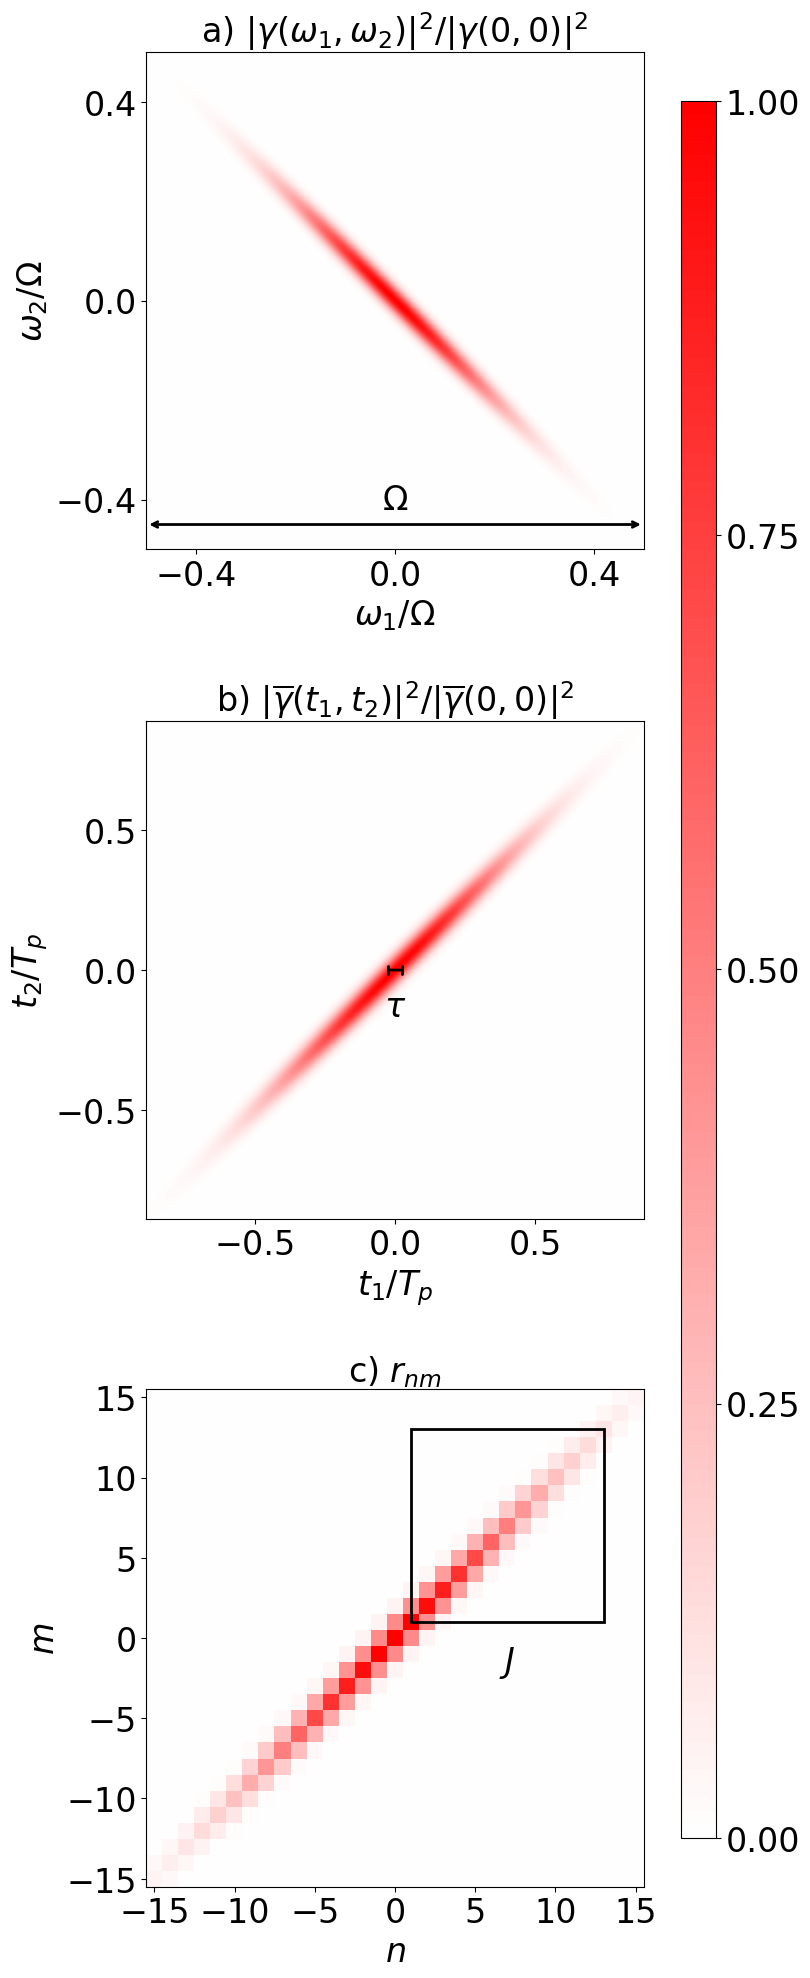

In [13]:
# Fig. 1

from matplotlib.patches import Rectangle
fsize=24

#ratio of sigc/sigp
ratio = 15

Tp = 1
Tc = Tp / ratio


# double gaussian in frequency
def wdubgauss(w1,w2):
    return np.sqrt(Tc*Tp/(np.pi**2))*np.exp(-((w1-w2)*Tc/(2*np.sqrt(np.pi)))**2)*np.exp(-((w1+w2)*Tp/(2*np.sqrt(np.pi)))**2)

# double gaussian in time
def dubgauss(t1,t2):
    return np.sqrt(1/(Tc*Tp))*np.exp(-(np.sqrt(np.pi)*(t1-t2)/(2*Tc))**2)*np.exp(-(np.sqrt(np.pi)*(t1+t2)/(2*Tp))**2)

# rnm matrix of double gaussian
def rnm_dg_plotting(n,m):
    return np.exp( -np.pi * ((n-m)**2) / 4 - ((Tc/Tp)**2) * np.pi * ((n+m)**2) / 4)



fig, axs = plt.subplots(3,1, figsize=(8,20), constrained_layout=True)
colormap = "bwr"
norm = mcolors.TwoSlopeNorm(vmin=-0.01, vcenter=0, vmax=1)
ticks = [0, 0.25, 0.5, 0.75, 1]
tick_labels = ['Low', 'Mid-Low', 'Zero', 'Mid-High', 'High']

tdim=0.5*np.sqrt(np.pi)

Omega=2*np.pi/Tc
tau=Tc

wdim=Omega/2


#discrete values for rnm
num=ratio
nvals=range(-num,num+1)
mvals=range(-num,num+1)
ns, ms = np.meshgrid(nvals, mvals)


# generating joint temporal amplitude

x = np.linspace(-tdim, tdim, 1000)
y = np.linspace(-tdim, tdim, 1000)
x, y = np.meshgrid(x, y)
zdg = (dubgauss(x, y)/dubgauss(0, 0))**2


# generating joint spectral amplitude
x = np.linspace(-wdim, wdim, 1000)
y = np.linspace(-wdim, wdim, 1000)
x, y = np.meshgrid(x, y)
sigc=1/(2*np.sqrt(np.pi))
sigp=sigc/ratio
zwdg = (wdubgauss(x, y)/wdubgauss(0, 0))**2

# generating r_nm matrix
zWSdg = rnm_dg_plotting(ns, ms)


wdim=0.5
im = axs[0].imshow(zwdg, extent=[-wdim, wdim, -wdim, wdim], origin='lower', cmap=colormap, norm=norm, aspect='auto')
axs[0].set(aspect='equal')
axs[0].set_title(r"a) $|\gamma(\omega_1,\omega_2)|^2/|\gamma(0,0)|^2$", fontsize=fsize)
axs[0].set_xlabel(r"$\omega_1/\Omega$", fontsize=fsize)
axs[0].set_ylabel(r"$\omega_2/\Omega$", fontsize=fsize)
axs[0].tick_params(axis='both', which='major', labelsize=fsize)
axs[0].set_xticks([-0.4,0,0.4])
axs[0].set_yticks([-0.4,0,0.4])
axs[0].annotate(
    "", 
    xy=(-0.5, -0.45), 
    xytext=(0.5, -0.45),
    arrowprops=dict(
        arrowstyle="<->",
        color='black',
        lw=2
    )
)
axs[0].text(0, -0.4, r"$\Omega$", ha='center', va='center', fontsize=fsize)


im = axs[1].imshow(zdg, extent=[-tdim, tdim, -tdim, tdim], origin='lower', cmap=colormap, norm=norm, aspect='auto')
axs[1].set(aspect='equal')
axs[1].set_title(r"b) $|\overline{\gamma}(t_1,t_2)|^2/|\overline{\gamma}(0,0)|^2$", fontsize=fsize)
axs[1].set_xlabel(r"$t_1/T_p$", fontsize=fsize)
axs[1].set_ylabel(r"$t_2/T_p$", fontsize=fsize)
axs[1].tick_params(axis='both', which='major', labelsize=fsize)
axs[1].annotate(
    "", 
    xy=(-tau/2, 0), 
    xytext=(tau/2, 0),
    arrowprops=dict(
        arrowstyle="|-|",
        color='black',
        lw=2,
        mutation_scale=3
    )
)
axs[1].text(0, -0.13, r"$\tau$", ha='center', va='center', fontsize=fsize)

t0=7
T=12

rect = Rectangle((t0-T/2,t0-T/2),T,T,linewidth=2,edgecolor='black',facecolor='none')
axs[2].add_patch(rect)

dim = len(zWSdg)
im = axs[2].imshow(zWSdg, extent=[-dim/2, dim/2, -dim/2, dim/2], origin='lower', cmap=colormap, norm=norm, aspect='auto')
axs[2].set(aspect='equal')
axs[2].set_title(r"c) $r_{nm}$", fontsize=fsize)
axs[2].set_xlabel(r"$n$", fontsize=fsize)
axs[2].set_ylabel(r"$m$", fontsize=fsize)
axs[2].set_xticks([-15,-10,-5,0,5,10,15])
axs[2].set_yticks([-15,-10,-5,0,5,10,15])
axs[2].tick_params(axis='both', which='major', labelsize=fsize)
axs[2].text(t0, -1.5, r"$J$", ha='center', va='center', fontsize=fsize)


tvals=np.linspace(-ratio, ratio, num=1000)
cbar = fig.colorbar(im, ax=axs[:], aspect=50, shrink=0.9, location="right")
cbar.ax.set_ylim(0,1)
cbar.set_ticks(ticks)
cbar.ax.tick_params(labelsize=fsize)
plt.savefig("DGfig_Vert.pdf", bbox_inches='tight')
plt.show()

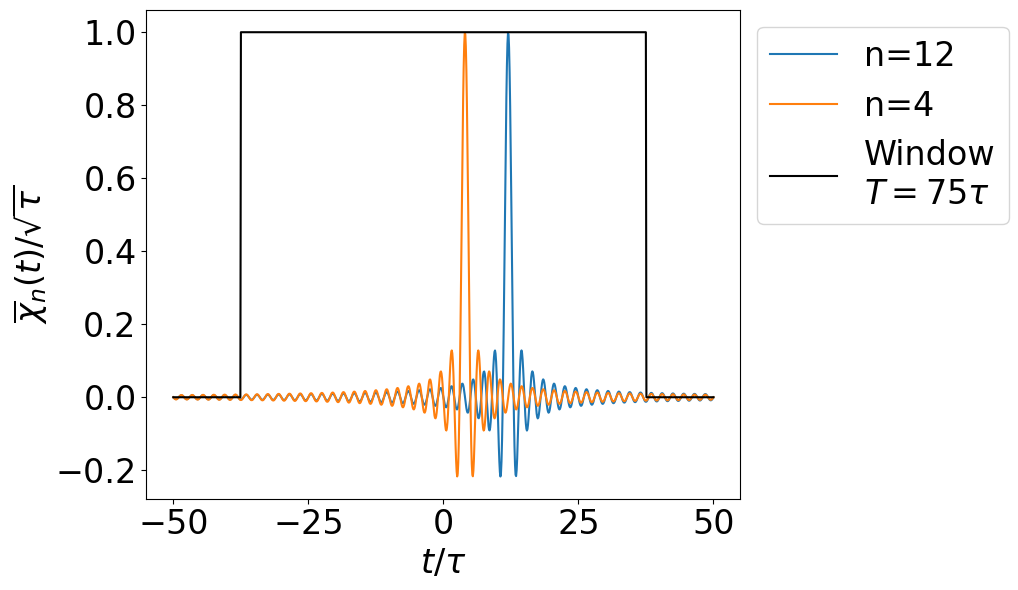

In [4]:
# Fig. 3

Tp=10
Tc=1
Omp=2*np.pi/Tp
Omc=2*np.pi/Tc
sigp=1
sigc=10
fsize=24

#Whittaker-Shannon mode functions
def chi(n,t,T):
    return np.sinc(t/T-n)/np.sqrt(T)

def chi2(n,t,T):
    return (np.sinc(t/T-n)/np.sqrt(T))**2


def window(t,T):
    return np.heaviside(t+T/2,1)-np.heaviside(t-T/2,1)


fig, axs = plt.subplots(1, 1, figsize=(10.5, 6))

tvals=np.linspace(-50, 50, num=1000)


axs.plot(tvals,chi(12,tvals,1), label="n=12")
axs.plot(tvals,chi(4,tvals,1), label="n=4")
axs.plot(tvals, window(tvals,75), color="black", label="Window\n"+r"$T=75\tau$")
axs.set_xlabel(r'$t/\tau$', fontsize=fsize)
axs.set_ylabel(r"$\overline{\chi}_n(t)/\sqrt{\tau}$", fontsize=fsize)
axs.legend(fontsize=fsize, bbox_to_anchor=(1, 1))
axs.tick_params(axis='both', which='major', labelsize=fsize)
plt.tight_layout()
plt.savefig("ChiWindow.pdf")
plt.show()

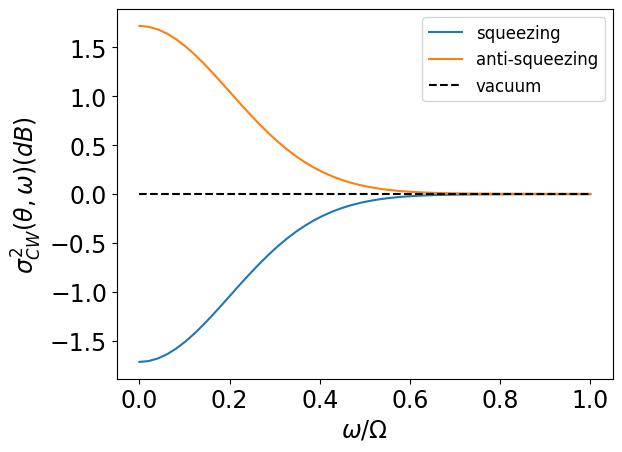

In [18]:
# Fig. 4

fsize=17
Tc=1
Bc = 0.1
fine_param = 2
mat_size = 30 * fine_param

r = r_dg_f_CW(mat_size,0,fine_param)

#plotting V(w) vs. theta at w
Omega = 2 * np.pi / Tc
w_vals=np.linspace(0,2,50)

B = Bc * r
U, Q = sc.linalg.polar(B, side = "left")
sinhQ = sc.linalg.sinhm(Q)
coshQ = sc.linalg.coshm(Q)
sinh2Q = np.linalg.matrix_power(sinhQ,2)

sq_list = []
anti_sq_list = []

for w in w_vals:
    sq_list.append(V(w * Omega / 2, np.pi/2,U,sinhQ,coshQ,sinh2Q,Tc,fine_param))
    anti_sq_list.append(V(w * Omega / 2, np.pi,U,sinhQ,coshQ,sinh2Q,Tc,fine_param))

plt.plot(w_vals / 2, 10*np.log10(np.real(np.array(sq_list)/len(Q))), label="squeezing")
plt.plot(w_vals / 2, 10*np.log10(np.real(np.array(anti_sq_list)/len(Q))), label="anti-squeezing")
plt.xlabel(r"$\omega/\Omega$")
plt.ylabel(r"$\sigma^2_{CW}(\theta, \omega) (dB)$")
plt.yticks([-1.5,-1,-0.5,0,0.5,1,1.5])
plt.hlines(0, 0, 1, color="black", linestyle="dashed", label="vacuum")
plt.legend(loc="upper right", fontsize=fsize-5)
plt.savefig("Homo_CW.pdf", bbox_inches='tight')
plt.show()

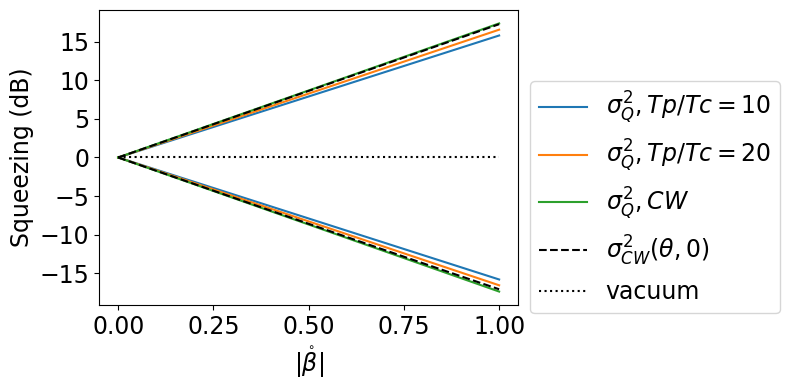

In [17]:
# Fig. 5

fsize=17
Tp=1
Bc = 0.1
fine_param = 1
mat_size = 30 * fine_param

plt.figure(figsize=(8,4))

Omega = 2 * np.sqrt(np.pi) / (Tc * fine_param)
Bc_vals = np.linspace(0,1,50)
Tc_vals = [0.1,0.05]
for Tc in Tc_vals:
    Sq_Pulsed = []
    anti_Sq_Pulsed = []
    
    ratio = Tc / Tp
    for Bc in Bc_vals:        
        r = r_dg_f(mat_size,0,fine_param,ratio)
        B = Bc * r   
        U, P = sc.linalg.polar(B, side = "right")
        sinhP = sc.linalg.sinhm(P)
        coshP = sc.linalg.coshm(P)
        sinh2P = np.linalg.matrix_power(sinhP,2)
        N = sinh2P
        M = np.linalg.multi_dot([coshP,sinhP,U.T])
        evals, evecs = np.linalg.eig(Kmat(N,M))
        Sq_Pulsed.append(1 + 2 * np.min(evals))
        anti_Sq_Pulsed.append(1 + 2 * np.max(evals))
    if Tc==0.1:
        col = "C0"
    else:
        col = "C1"
    plt.plot(Bc_vals,10*np.log10(np.real(np.array(Sq_Pulsed))), label="$\sigma^2_Q, Tp/Tc=$"+str(int(1/Tc)), color=col)
    plt.plot(Bc_vals,10*np.log10(np.real(np.array(anti_Sq_Pulsed))), color=col)

Sq_Pulsed = []
anti_Sq_Pulsed = []
for Bc in Bc_vals:        
    r = r_dg_f_CW(mat_size,0,fine_param)
    B = Bc * r   
    U, P = sc.linalg.polar(B, side = "right")
    sinhP = sc.linalg.sinhm(P)
    coshP = sc.linalg.coshm(P)
    sinh2P = np.linalg.matrix_power(sinhP,2)
    N = sinh2P
    M = np.linalg.multi_dot([coshP,sinhP,U.T])
    evals, evecs = np.linalg.eig(Kmat(N,M))
    Sq_Pulsed.append(1 + 2 * np.min(evals))
    anti_Sq_Pulsed.append(1 + 2 * np.max(evals))
plt.plot(Bc_vals,10*np.log10(np.real(np.array(Sq_Pulsed))), label=r"$\sigma^2_Q, CW$", color="C2")
plt.plot(Bc_vals,10*np.log10(np.real(np.array(anti_Sq_Pulsed))), color="C2")
 

Sq_CW = []
anti_Sq_CW = []
Tc = 0.002
for Bc in Bc_vals:
    B = Bc * r_dg_f_CW(mat_size,0,fine_param)
    U, Q = sc.linalg.polar(B, side = "left")
    sinhQ = sc.linalg.sinhm(Q)
    coshQ = sc.linalg.coshm(Q)
    sinh2Q = np.linalg.matrix_power(sinhQ,2)
    Sq_CW.append(Sq(0,U,sinhQ,coshQ,sinh2Q,Tc,fine_param))
    anti_Sq_CW.append(anti_Sq(0,U,sinhQ,coshQ,sinh2Q,Tc,fine_param))


plt.plot(Bc_vals,10*np.log10(np.real(np.array(Sq_CW))), label=r"$\sigma^2_{CW}(\theta,0)$", linestyle="dashed", color="black")
plt.plot(Bc_vals,10*np.log10(np.real(np.array(anti_Sq_CW))), linestyle="dashed", color="black")
plt.ylabel(r"Squeezing (dB)")
plt.xlabel(r"$|\mathring{\beta}|$")
plt.yticks([-15,-10,-5,0,5,10,15])
plt.hlines(0,Bc_vals[0],Bc_vals[-1], label="vacuum", color="black", linestyle="dotted")
plt.legend(fontsize=fsize, bbox_to_anchor=(1,0.8))
plt.tight_layout()
plt.savefig("Homo_Sq.pdf")
plt.show()

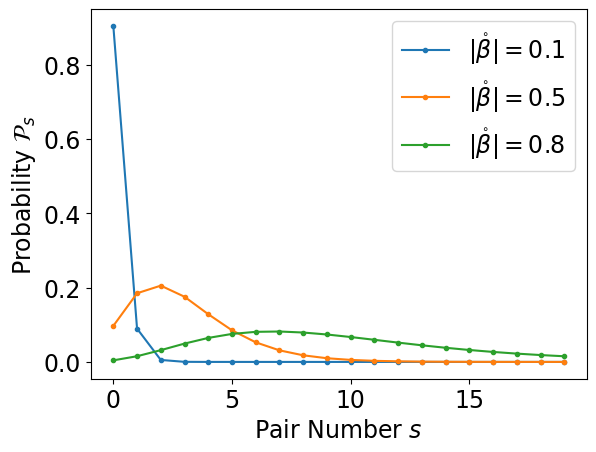

In [7]:
# Fig. 7

fsize=17
Bclist = [0.1,0.5,0.8]
ratio = 0.1
fine_param = 1
mat_size = 15 * fine_param
s_list = range(20)

for bc in Bclist:

    Bc = bc
    B = Bc * r_dg_f(mat_size,0,fine_param, ratio)
    U, Q = sc.linalg.polar(B, side = "left")
    detW = 1 / np.linalg.det(sc.linalg.coshm(Q))
    T = np.matmul(sc.linalg.tanhm(Q),U)   
    N = np.trace(np.linalg.matrix_power(sc.linalg.sinhm(Q),2))

    Ps_list = [P_s(s,Q,detW) for s in s_list]
    plt.plot(s_list, Ps_list, marker=".", label=r"$|\mathring{\beta}|=$"+str(Bc))    


plt.xlabel("Pair Number $s$")
plt.ylabel(r"Probability $\mathcal{P}_s$")
plt.legend(fontsize=fsize)
plt.savefig("P_Num_Probs.pdf", bbox_inches='tight')

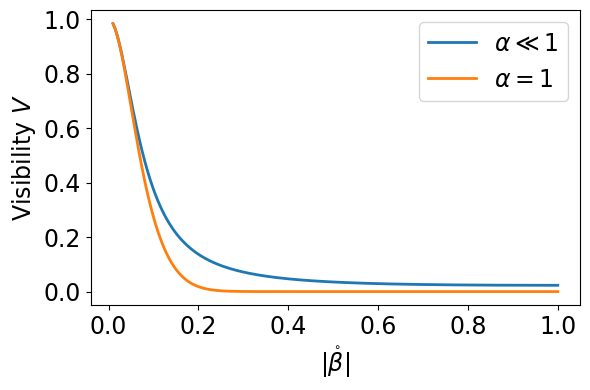

In [8]:
# Fig. 8

#plot line width
wsize=2
fsize=17
fine_param = 1
mat_size = 30 * fine_param
Bc_vals = np.linspace(0.01, 1, 200)
Vlow_list = []
V1_list = []
    
for bc in Bc_vals:
    Bc = bc
    B = Bc * r_dg_f_CW(mat_size,0,fine_param)
    U, Q = sc.linalg.polar(B, side = "left")
    detW = 1 / np.linalg.det(sc.linalg.coshm(Q))
    T = np.matmul(sc.linalg.tanhm(Q),U)   
    N = np.trace(np.linalg.matrix_power(sc.linalg.sinhm(Q),2))
    
    Vlow = (PHH_low(1,Q,N) - PHV_low(1,N)) / (PHH_low(1,Q,N) + PHV_low(1,N))
    V1 = (PHH_1(detW) - PHV_1(detW)) / (PHH_1(detW) + PHV_1(detW))
    
    Vlow_list.append(Vlow)
    V1_list.append(V1)  
    
plt.figure(figsize=(6,4))
plt.plot(Bc_vals, Vlow_list, label=r"$\alpha\ll 1$", linewidth=wsize)
plt.plot(Bc_vals, V1_list, label=r"$\alpha=1$", linewidth=wsize)
plt.ylabel(r"Visibility $V$")
plt.xlabel(r"$|\mathring{\beta}|$")
plt.legend(fontsize=fsize)
plt.tight_layout()
plt.savefig("Coincidence_Visibilities.pdf")
plt.show()

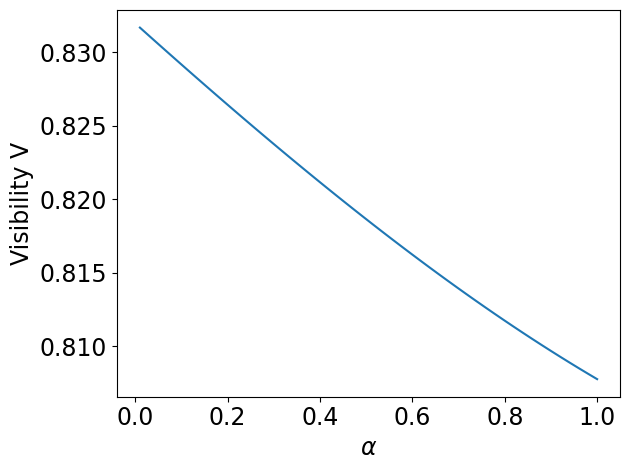

In [9]:
# Fig. 9

ratio = 0.1
Bc = 0.1
fine_param = 1
mat_size = 10 * fine_param

alpha_vals = np.linspace(0.01, 1, 50)

B = Bc * r_dg_f(mat_size,0,fine_param, ratio)
U, Q = sc.linalg.polar(B, side = "left")
detW = 1 / np.linalg.det(sc.linalg.coshm(Q))
T = np.matmul(sc.linalg.tanhm(Q),U)   
N = np.trace(np.linalg.matrix_power(sc.linalg.sinhm(Q),2))

Vweak_list = [(PHH_weak(a,N) - PHV_weak(a,N)) / (PHH_weak(a,N) + PHV_weak(a,N)) for a in alpha_vals]   
    
plt.plot(alpha_vals, Vweak_list)
plt.ylabel("Visibility V")
plt.xlabel(r"$\alpha$")
plt.tight_layout()
plt.savefig("Weak_Vis.pdf")
plt.show()

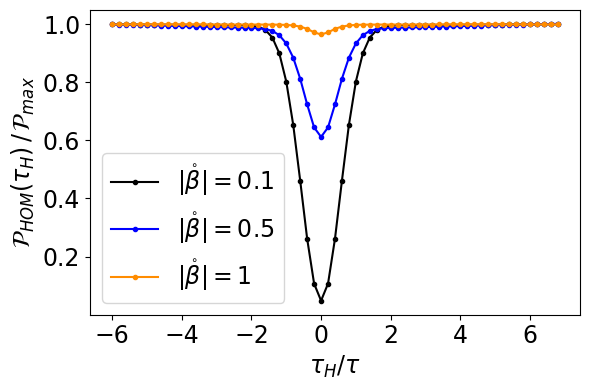

In [12]:
# Fig. 11

fsize=17
ratio = 0.1
fine_param = 5
klist=range(-6 * fine_param, 7 * fine_param)
mat_size = 30 * fine_param

def dg_dip(Bc):
    
    Plist=[]

    for k in klist:

        B = Bc * r_dg_f(mat_size,k,fine_param,ratio)

        U, Q = sc.linalg.polar(B, side = "left")
        detW =  1 / np.linalg.det(sc.linalg.coshm(Q))
        T = np.matmul(sc.linalg.tanhm(Q),U)
        L = 0.5 * (T + np.transpose(T))
        LdagL = np.dot(np.transpose(np.conjugate(L)),L)

        Prob = 1+(detW**2)*(1-2/np.sqrt(np.linalg.det(np.identity(len(L))-LdagL)))
        Plist.append(Prob)

    P_max = Plist[0]
    
    return np.real(Plist / P_max) 


Pvals_1 = dg_dip(0.1)
Pvals_5 = dg_dip(0.5)
Pvals_10 = dg_dip(1)

plt.figure(figsize=(6,4))
plt.plot(np.array(klist)/fine_param, Pvals_1, color="black", label=r"$|\mathring{\beta}|=0.1$", marker=".")
plt.plot(np.array(klist)/fine_param, Pvals_5, color="blue", label=r"$|\mathring{\beta}|=0.5$", marker=".")
plt.plot(np.array(klist)/fine_param, Pvals_10, color="darkorange", label=r"$|\mathring{\beta}|=1$", marker=".")
plt.xlabel(r"$\tau_H/\tau$")
plt.ylabel(r"$\mathcal{P}_{HOM}(\tau_H)\,/\,\mathcal{P}_{max}$")
plt.xticks(np.arange(-6,7, step=2))
plt.legend(fontsize=fsize)
plt.tight_layout()
plt.savefig("HOM_Dip.pdf")
plt.show()

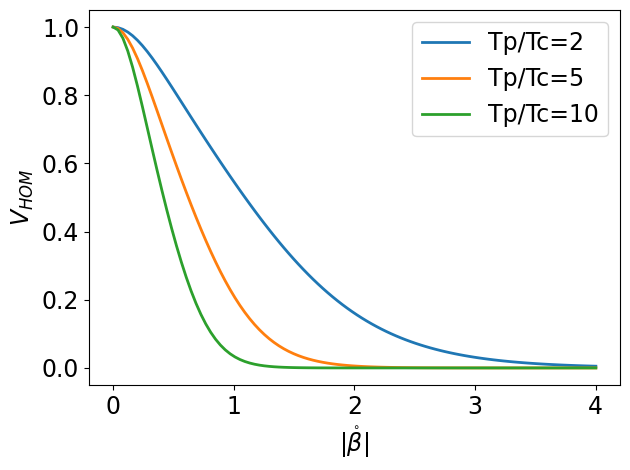

In [11]:
# Fig. 12

fsize = 17
wsize = 2

Bc_vals = np.linspace(0.001, 4, 100)

inv_ratios = [2,5,10]

fine_param = 1

for inv_rat in inv_ratios:
    
    rat = 1 / inv_rat
    V_list = []
     
    for Bc in Bc_vals:
    
        B = Bc * r_dg_f(30,0,fine_param,rat)
        U, Q = sc.linalg.polar(B, side = "left")
        U, P = sc.linalg.polar(B, side = "right")

        detW = 1 / np.linalg.det(sc.linalg.coshm(Q))
        T = np.matmul(sc.linalg.tanhm(Q),U)
        L = 0.5 * (T + np.transpose(T))    
        LdagL=np.dot(np.transpose(np.conjugate(L)),L)   
        P_min = 1 + (detW**2) * (1 - 2/np.sqrt(np.linalg.det(np.identity(len(L)) - LdagL)))
    
        tanhQ = sc.linalg.tanhm(Q)
        tanhP = sc.linalg.tanhm(P)
        tanh2Q = np.linalg.matrix_power(tanhQ,2)
        tanh2P = np.linalg.matrix_power(tanhP,2)

        det_max = np.linalg.det(np.identity(len(Q)) - 0.25*(tanh2Q))
        P_max = 1+(detW**2)*(1-2/det_max)

        V_list.append((P_max - P_min) / P_max)
        
    plt.plot(Bc_vals,V_list, label="Tp/Tc="+str(inv_rat), linewidth=wsize)


plt.xlabel(r"$|\mathring{\beta}|$")
plt.ylabel("$V_{HOM}$")
plt.tight_layout()
plt.legend(fontsize=fsize)
plt.savefig("HOM_V.pdf")
plt.show()